In [ ]:

import requests
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

In [ ]:

# ==============================
# 2. Endpoint e parametros de busca
# ==============================
BASE_URL = "https://pncp.gov.br/api/consulta/v1/contratos"

PARAMS_BASE = {
    "dataInicial": "20260101",
    "dataFinal": "20260411",
    "tamanhoPagina": 500
}

MAX_WORKERS = 10   
RETRIES = 3       

# ==============================
# 3. Função com retry
# ==============================
def fetch_page(page):
    params = PARAMS_BASE.copy()
    params["pagina"] = page

    for attempt in range(RETRIES):
        try:
            response = requests.get(BASE_URL, params=params, timeout=30)

            if response.status_code == 200:
                return response.json().get("data", [])
            
            else:
                print(f"Erro HTTP {response.status_code} na página {page}")

        except requests.exceptions.RequestException:
            print(f"Erro de conexão na página {page} (tentativa {attempt+1})")

        time.sleep(1)  # espera antes de tentar novamente

    return []  # se falhar tudo

# ==============================
# 4. Descobrir total de páginas
# ==============================
print("Consultando total de páginas...")

first_response = requests.get(BASE_URL, params={**PARAMS_BASE, "pagina": 1})
data = first_response.json()

total_paginas = data.get("totalPaginas", 1)

print(f"Total de páginas: {total_paginas}")

# ==============================
# 5. Coleta paralela
# ==============================
all_data = []

print("Baixando dados em paralelo...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(fetch_page, p): p for p in range(1, total_paginas + 1)}

    for future in tqdm(as_completed(futures), total=total_paginas):
        result = future.result()
        all_data.extend(result)

print(f"Total bruto coletado: {len(all_data)}")


In [ ]:
# ==============================
# 6. Normalizar JSON
# ==============================
df = pd.json_normalize(all_data)

print("Colunas disponíveis:")
print(df.columns.tolist())

# ==============================
# 7. Filtrar Ceará (CE)
# ==============================
if "unidadeOrgao.ufSigla" in df.columns:
    df_ce = df[df["unidadeOrgao.ufSigla"] == "CE"]
else:
    print("Coluna de UF não encontrada!")
    df_ce = df

print(f"Total CE: {len(df_ce)}")

for col in ["dataAssinatura", "dataVigenciaInicio", "dataVigenciaFim"]:
    if col in df_ce.columns:
        df_ce[col] = pd.to_datetime(df_ce[col], errors='coerce')

# ==============================
# 💾 9. Salvar CSV
# ==============================
output_file = "contratos_ceara.csv"

df_ce.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Arquivo salvo como: {output_file}")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

data = pd.read_csv('../data/contratos_ceara.csv')

print("numero de linhas e colunas ")
data.shape

numero de linhas e colunas 


(22631, 57)

In [4]:
data.isnull().sum() 

numeroControlePncpCompra              0
codigoPaisFornecedor               1312
receita                               0
numeroParcelas                        0
numeroRetificacao                     0
tipoPessoaSubContratada           22615
objetoContrato                        0
valorInicial                          0
valorParcela                          0
valorGlobal                           0
valorAcumulado                    10867
identificadorCipi                 21506
urlCipi                           21509
dataAtualizacao                       0
dataAssinatura                        0
dataVigenciaInicio                    0
dataVigenciaFim                       0
niFornecedor                          0
tipoPessoa                            0
processo                             61
orgaoSubRogado                    22631
unidadeSubRogada                  22631
nomeRazaoSocialFornecedor             0
informacaoComplementar            22192
numeroContratoEmpenho                 0


In [5]:
## Ajustando colunas 

data["codigoPaisFornecedor"] = "BRA"

data = data.drop(columns=["urlCipi"], errors="ignore")
data = data.drop(columns=["identificadorCipi"], errors="ignore")
data = data.drop(columns=["orgaoSubRogado"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada"], errors="ignore")
data = data.drop(columns=["orgaoSubRogado.cnpj"], errors="ignore")
data = data.drop(columns=["orgaoSubRogado.razaoSocial"], errors="ignore")
data = data.drop(columns=["orgaoSubRogado.esferaId"], errors="ignore")
data = data.drop(columns=["orgaoSubRogado.poderId"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada.codigoUnidade"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada.ufSigla"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada.municipioNome"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada.nomeUnidade"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada.codigoIbge"], errors="ignore")
data = data.drop(columns=["unidadeSubRogada.ufNome"], errors="ignore")
data = data.drop(columns=["niFornecedorSubContratado"], errors="ignore")
data = data.drop(columns=["nomeFornecedorSubContratado"], errors="ignore")
data = data.drop(columns=["tipoPessoaSubContratada"], errors="ignore")
data = data.drop(columns=["informacaoComplementar"], errors="ignore")


# Deixar em ordem alfabetica pelo nome do municipio

data = data.sort_values(by="unidadeOrgao.municipioNome", ascending=True)

# Deixa essa coluna numerica
data['valorGlobal'] = pd.to_numeric(data['valorGlobal'], errors='coerce')




In [7]:
data.to_csv('../data/contratos_ceara_limpo.csv', index=False, encoding='utf-8')

Quantidade de contratos feitas por cada municipio
unidadeOrgao.municipioNome
Fortaleza       7353
Caucaia          443
Irauçuba         420
Quixeramobim     408
Horizonte        400
                ... 
Mulungu            2
Orós               2
Penaforte          2
Palhano            1
Potengi            1
Name: count, Length: 182, dtype: int64


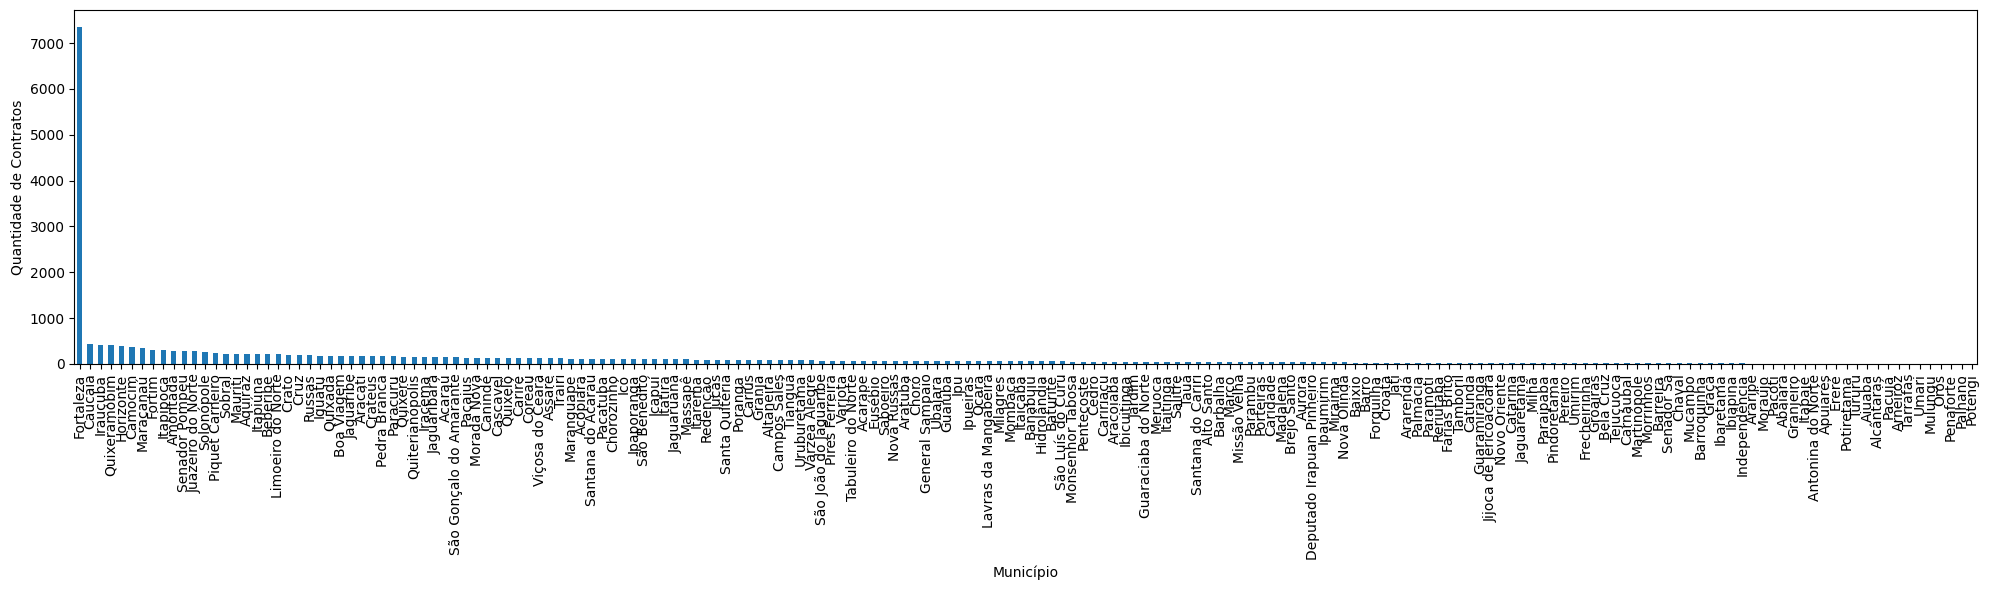

In [8]:
tops = data['unidadeOrgao.municipioNome'].value_counts()

print("Quantidade de contratos feitas por cada municipio")
print(tops)

plt.figure(figsize=(20, 6))
tops.plot(kind='bar')

plt.xlabel('Município')
plt.ylabel('Quantidade de Contratos')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
stats = data.groupby("unidadeOrgao.municipioNome")["valorGlobal"].describe()

C:\Users\erica\AppData\Local\Temp\ipykernel_30664\2324601188.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="valorGlobal", y="unidadeOrgao.municipioNome", data=data_filtrada, palette="viridis")


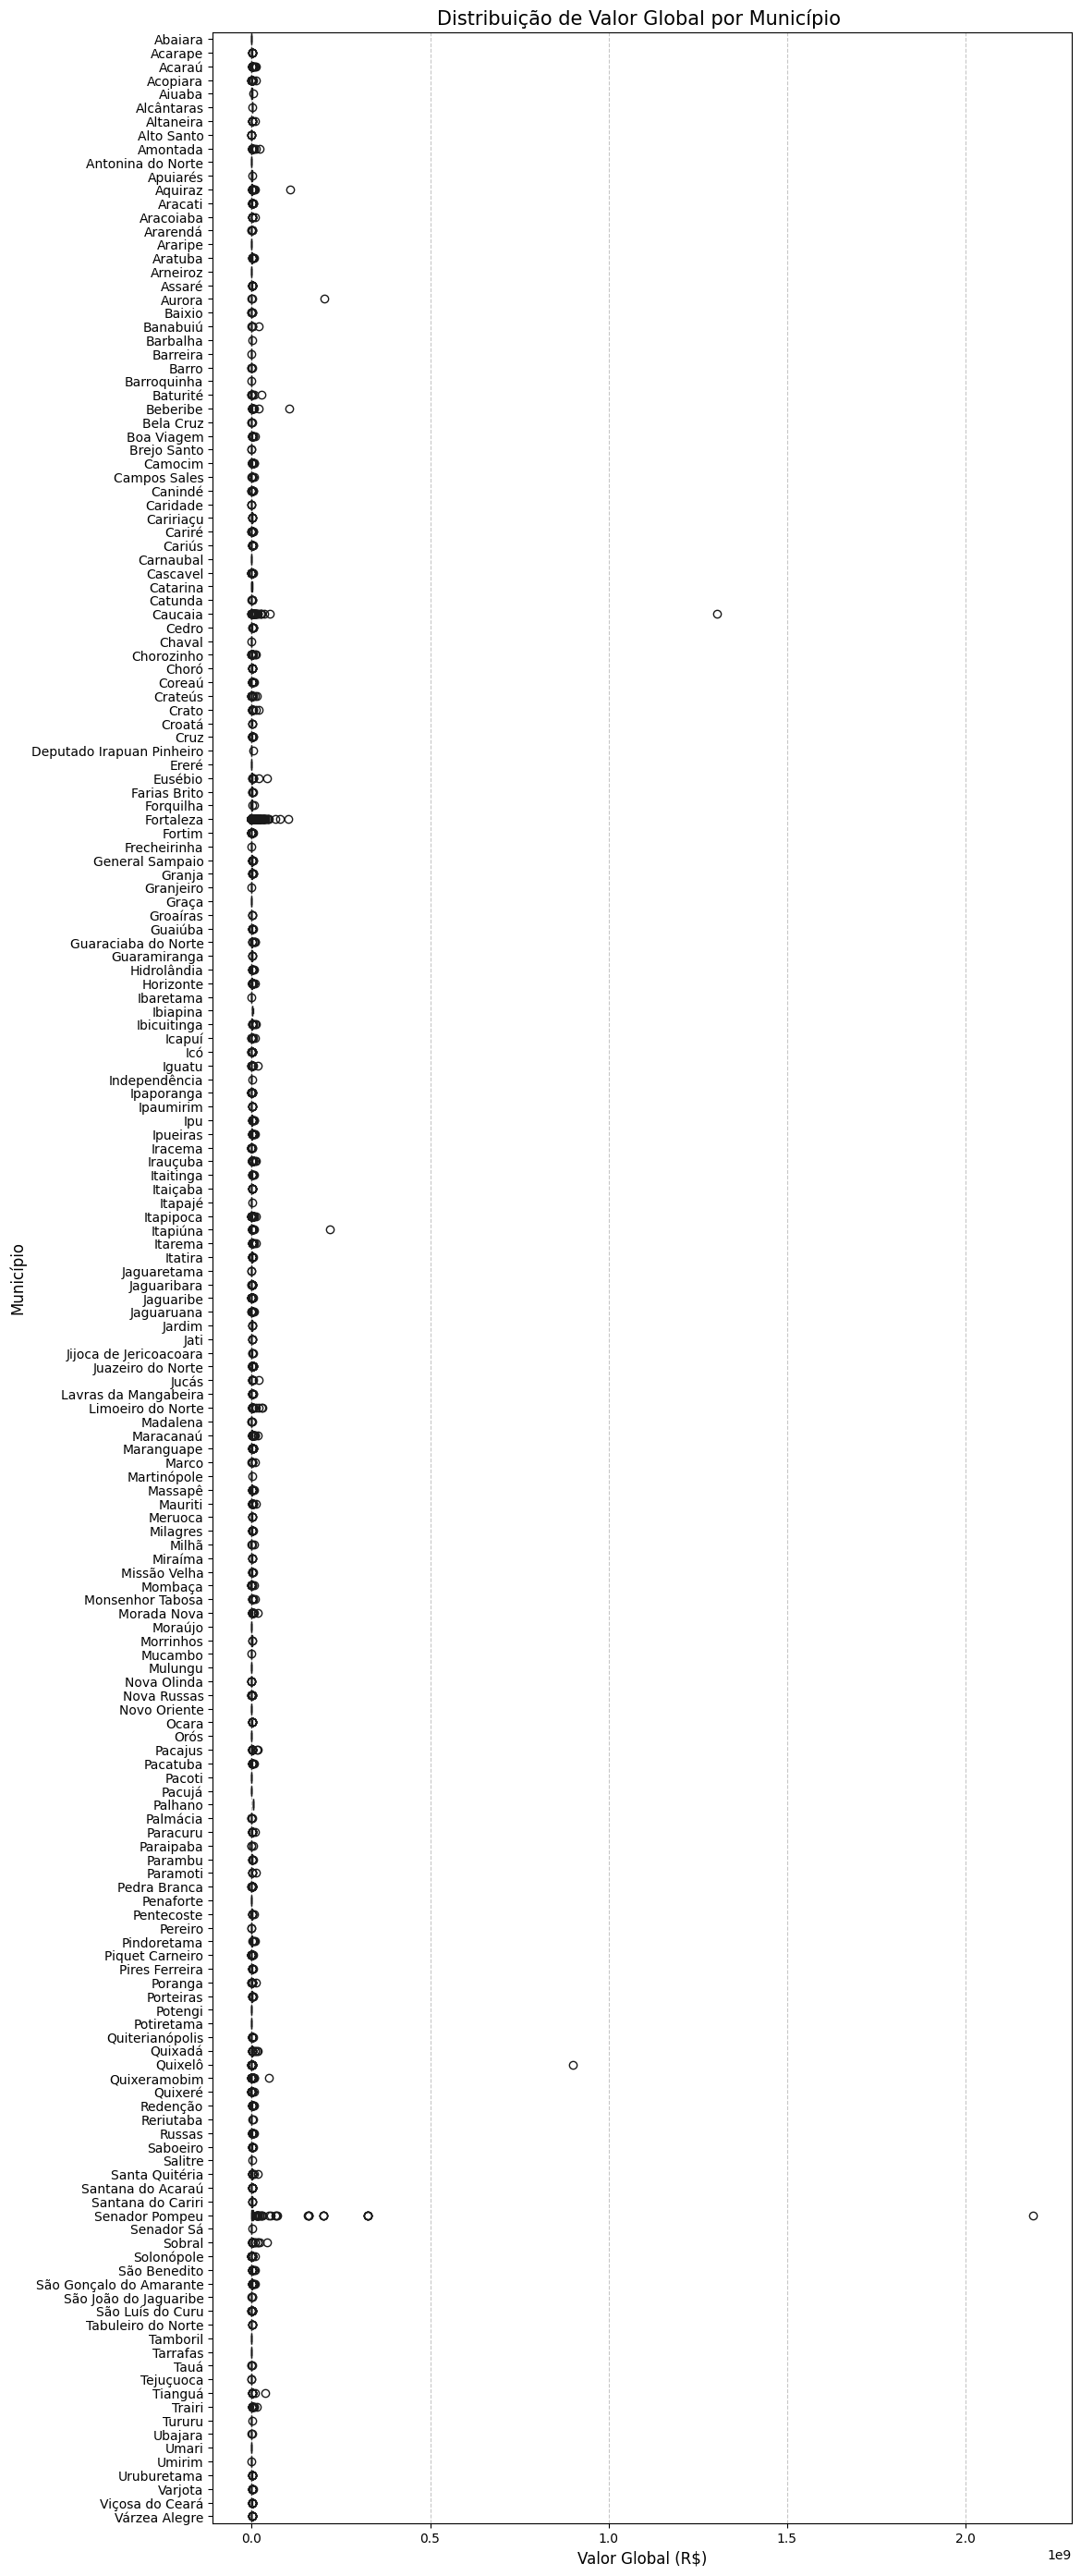

In [10]:

plt.figure(figsize=(12, 35))


desc_media_valorGlobal = stats.sort_values(by="mean", ascending=False).head(187).index
data_filtrada = data[data["unidadeOrgao.municipioNome"].isin(desc_media_valorGlobal)]


sns.boxplot(x="valorGlobal", y="unidadeOrgao.municipioNome", data=data_filtrada, palette="viridis")


plt.title("Distribuição de Valor Global por Município ", fontsize=15)
plt.xlabel("Valor Global (R$)", fontsize=12)
plt.ylabel("Município", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [54]:
maior_por_municipio = data.groupby("unidadeOrgao.municipioNome")["valorGlobal"].max().sort_values(ascending=False)

print(maior_por_municipio)


unidadeOrgao.municipioNome
Senador Pompeu       2.189450e+09
Caucaia              1.303265e+09
Quixelô              9.005271e+08
Itapiúna             2.194902e+08
Aurora               2.045600e+08
                         ...     
Antonina do Norte    1.606000e+04
Ibaretama            1.512000e+04
Mulungu              8.310980e+03
Tarrafas             3.971190e+03
Potengi              1.860000e+03
Name: valorGlobal, Length: 182, dtype: float64


In [55]:
import plotly.graph_objects as go

# 1. Ordenando (do maior para o menor)
stats_sorted = stats.sort_values(by="mean", ascending=True) # Ascending True para o maior ficar no topo no gráfico horizontal

# 2. Criando a figura
fig = go.Figure()

fig.add_trace(go.Bar(
    y=stats_sorted.index,  # Municípios no eixo Y agora
    x=stats_sorted['mean'], # Valores no eixo X
    orientation='h',        # Transforma em barras horizontais
    marker_color='royalblue',
    customdata=stats_sorted[['min', 'std', '25%', '50%', '75%', 'max']],
    hovertemplate="<br>".join([
        "<b>Município: %{y}</b>",
        "Média: R$ %{x:,.2f}",
        "Desvio Padrão (std): R$ %{customdata[1]:,.2f}", 
        "Mínimo: R$ %{customdata[0]:,.2f}",             
        "Máximo: R$ %{customdata[5]:,.2f}",            
        "<extra></extra>" 
    ])
))

# 3. Ajustando o Layout para acomodar 182 cidades
fig.update_layout(
    title='Estatísticas por Município (Arraste para ver todos)',
    xaxis_title='Média de Valor Global (R$)',
    yaxis_title='Municípios',
    # Aumentamos a altura para que cada cidade tenha seu espaço
    height=3000, 
    margin=dict(l=200), # Margem maior na esquerda para os nomes das cidades
    template="plotly_white"
)

fig.show()

In [ ]:
# Filtra o dataframe original e aplica o describe
describe_senador = data[data["unidadeOrgao.municipioNome"] == "Senador Pompeu"]["valorGlobal"].describe()

print(describe_senador)